# iCCF S2D Preview

Preview how to calculate a CCF from one S2D FITS file using `iccf-make-ccf`, inspect the output FITS, and flatten the CCF into an ML-style row.

In [31]:
from pathlib import Path
import numpy as np
import json
import pandas as pd
from generate_real_s1d_iccf_dataset import generate_real_s1d_iccf_dataset

import matplotlib.pyplot as plt


In [32]:
from generate_real_s1d_iccf_dataset import (
    collect_input_files,
    build_rvarray,
    calculate_real_s1d_iccf_rows,
    rows_to_dataframe,
    save_real_s1d_iccf_dataset,
    generate_real_s1d_iccf_dataframe,
)


In [33]:
df = generate_real_s1d_iccf_dataframe(
    input_dir="./S1D_spectra/sun_harpsN/",
    recursive=True,
    pattern="*.fits",
    mask_name="G2",
    mask_instrument="HARPS",
    mask_width=0.5,
    vrad_min=-15,
    vrad_max=15,
    vrad_step=0.1,
    show_progress=True,
)

# Normalize each row by its maximum CCF value, exactly as in process_ccf.py
ccf_cols = [col for col in df.columns if col.startswith("ccf_")]
row_max = df[ccf_cols].max(axis=1).replace(0, np.nan)
df[ccf_cols] = df[ccf_cols].div(row_max, axis=0)
df[ccf_cols] = df[ccf_cols].round(4)

df.head()


S1D -> iCCF:   0%|          | 0/168 [00:00<?, ?file/s]

,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,source_file,source_path,object,date_obs,...,ccf_0291,ccf_0292,ccf_0293,ccf_0294,ccf_0295,ccf_0296,ccf_0297,ccf_0298,ccf_0299,ccf_0300
0,109.407896,7.052289,-63.548202,-56.505718,98.467253,56.486953,r.HARPN.2018-07-01T08-25-15.495_S1D_A.fits,S1D_spectra/sun_harpsN/2018-06-30/r.HARPN.2018...,Sun,2018-07-01T08:25:15.495,...,0.9994,0.9995,0.9997,0.9996,0.9996,0.9995,0.9995,0.9995,0.9995,0.9996
1,110.036770,7.047217,-62.814406,-55.647278,88.587273,56.558434,r.HARPN.2018-07-01T09-02-50.072_S1D_A.fits,S1D_spectra/sun_harpsN/2018-07-01/r.HARPN.2018...,Sun,2018-07-01T09:02:50.072,...,0.9995,0.9996,0.9997,0.9996,0.9995,0.9994,0.9994,0.9993,0.9994,0.9995
2,107.301250,7.038449,-63.940648,-55.952025,59.130443,56.693433,r.HARPN.2018-07-02T11-36-18.794_S1D_A.fits,S1D_spectra/sun_harpsN/2018-07-02/r.HARPN.2018...,Sun,2018-07-02T11:36:18.794,...,0.9990,0.9991,0.9992,0.9992,0.9991,0.9990,0.9990,0.9989,0.9989,0.9990
3,108.283038,7.048594,-64.755423,-57.114886,86.470363,56.544188,r.HARPN.2018-07-03T09-04-01.345_S1D_A.fits,S1D_spectra/sun_harpsN/2018-07-03/r.HARPN.2018...,Sun,2018-07-03T09:04:01.345,...,0.9990,0.9991,0.9992,0.9992,0.9992,0.9991,0.9990,0.9990,0.9990,0.9992
4,108.072925,7.043501,-65.039538,-56.697248,72.303851,56.615428,r.HARPN.2018-07-04T09-27-25.909_S1D_A.fits,S1D_spectra/sun_harpsN/2018-07-04/r.HARPN.2018...,Sun,2018-07-04T09:27:25.909,...,0.9990,0.9990,0.9992,0.9992,0.9991,0.9991,0.9990,0.9989,0.9990,0.9990


In [38]:
df.to_csv("./sun_harpsN_real_ccf_model_input_normalized.csv", index=False)

In [35]:
(-1018.462479 + 224.07597700000002)/1000+15


14.205613498

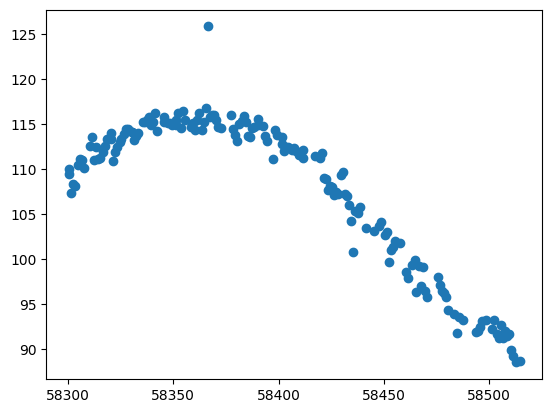

In [39]:
plt.scatter(df['mjd_obs'], df['rv_iccf_mps'])

In [37]:

#df = generate_real_s1d_iccf_dataset(
#    input_dir="./S1D_spectra",
#    output_csv="./real_s1d_iccf_dataset.csv",
#)
